<a href="https://colab.research.google.com/github/negilbabu/Heart-Disease-Prediction-Ai-/blob/dev/HeartDiseasePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!apt-get update
!apt-get install git

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:6 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/abdelDebug/Heart-Disease-Data/refs/heads/main/heart_disease.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [ ]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0


In [ ]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,2.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,0.600660,0.663366,1.831683,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.934375,0.956705,0.499120
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,1.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,3.000000,1.000000


In [ ]:
df.shape

(303, 14)

In [ ]:
df["target"].unique()

array([0, 1])

In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
print("Checking for null values....")
count = df.isnull().sum()
for col, null_count in count.items():
    if null_count > 0:
        print(f"Column '{col}' has {null_count} null values. Removing null values...")
        df = df.dropna(subset=[col])

    else:
        print(f"Column '{col}' has no null values.")
print("Shape of dataframe", df.shape)

Checking for null values....
Column 'age' has no null values.
Column 'sex' has no null values.
Column 'cp' has no null values.
Column 'trestbps' has no null values.
Column 'chol' has no null values.
Column 'fbs' has no null values.
Column 'restecg' has no null values.
Column 'thalach' has no null values.
Column 'exang' has no null values.
Column 'oldpeak' has no null values.
Column 'slope' has no null values.
Column 'ca' has no null values.
Column 'thal' has no null values.
Column 'target' has no null values.
Shape of dataframe (303, 14)


In [ ]:
print("Checking for duplicated rows:")
duplicated_rows = df.duplicated()
print(f"Total duplicated rows: {duplicated_rows.sum()}")

if duplicated_rows.any():
    df_removed_duplicates = df.drop_duplicates()
    print("Shape of dataframe after removing duplicates", df_removed_duplicates.shape)

Checking for duplicated rows:
Total duplicated rows: 0


Exploratory Data Analysis

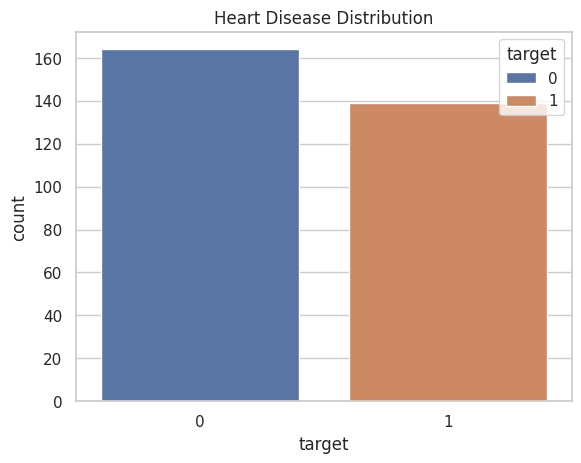

In [ ]:
sns.set(style="whitegrid")

sns.countplot(x='target',hue='target', data=df)
plt.title('Heart Disease Distribution')

plt.show()

People with heart disease are less than those without heart disease

<Axes: xlabel='age', ylabel='Count'>

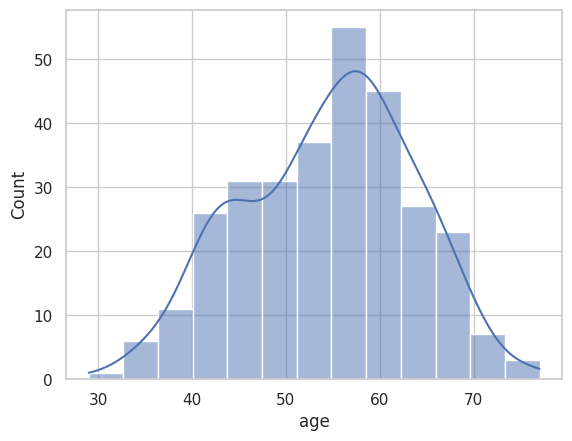

In [ ]:
sns.histplot(df['age'], kde=True)

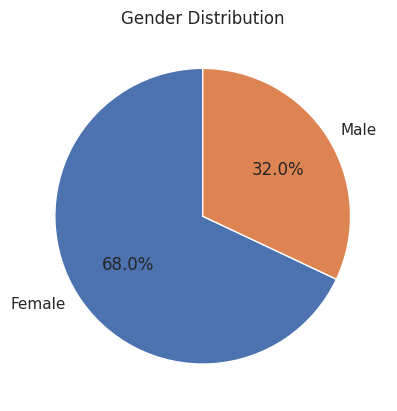

In [ ]:
# Mapping gender values to labels
gender_mapping = {0: 'Male', 1: 'Female'}
df_mapped = df.copy()
df_mapped['Gender'] = df_mapped['sex'].map(gender_mapping)

gender_counts = df_mapped['Gender'].value_counts()
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Gender Distribution')
plt.show()

Pie chart shows that number of females are more in the dataset than men.

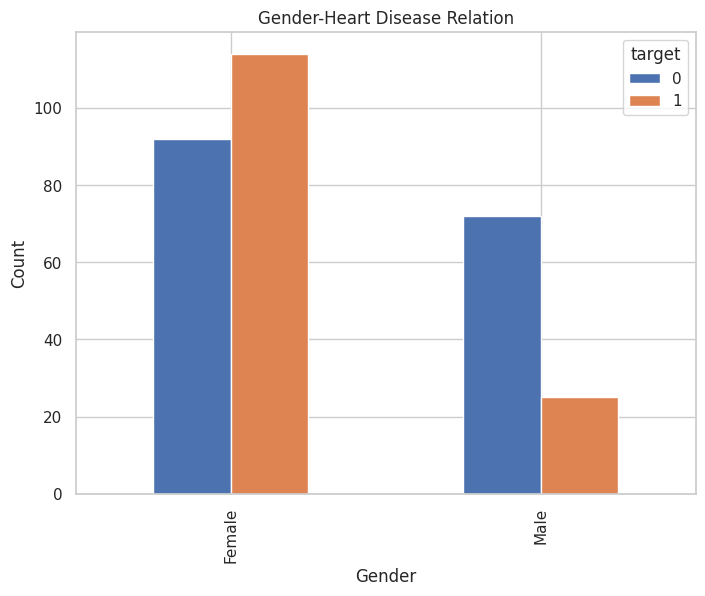

In [ ]:
gender_disease_relation = df_mapped.groupby(['Gender', 'target'])['target'].count().unstack()

gender_disease_relation.plot(kind='bar', stacked=False, figsize=(8,6))
plt.title('Gender-Heart Disease Relation')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

Plot shows that heart diseases are more often in females when comparing to male

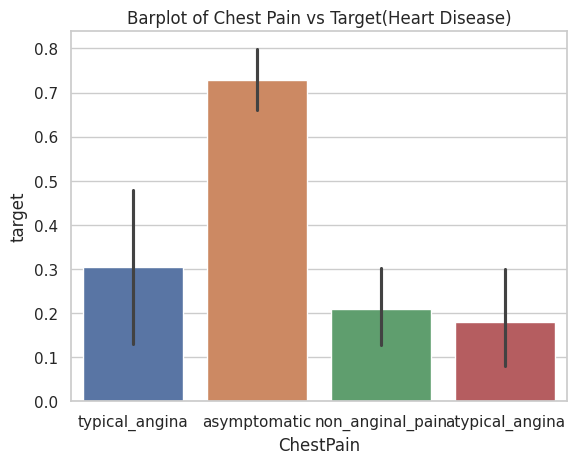

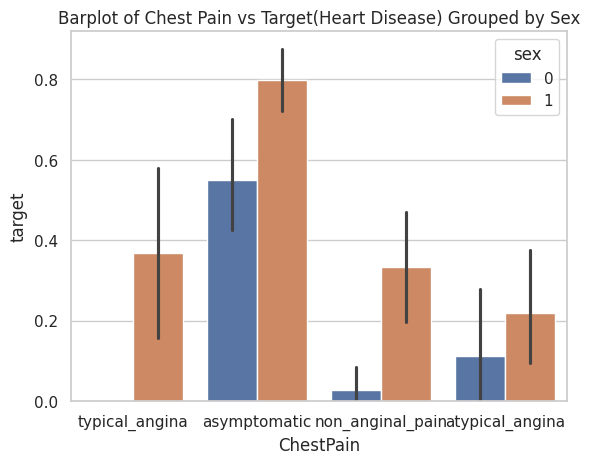

In [ ]:
cp_mapping = {0: 'typical_angina', 1: 'atypical_angina', 2: 'non_anginal_pain', 3: 'asymptomatic'}
df_mapped['ChestPain'] = df_mapped['cp'].map(cp_mapping)

sns.barplot(x="ChestPain", y="target",hue='ChestPain', data=df_mapped)
plt.title("Barplot of Chest Pain vs Target(Heart Disease)")
plt.show()

sns.barplot(x="ChestPain", y="target",hue='sex', data=df_mapped)
plt.title("Barplot of Chest Pain vs Target(Heart Disease) Grouped by Sex")
plt.show()


This barplot depicts that the people with asymptomatic chest pain has the higher chances of having a heart disease while comparing with others.


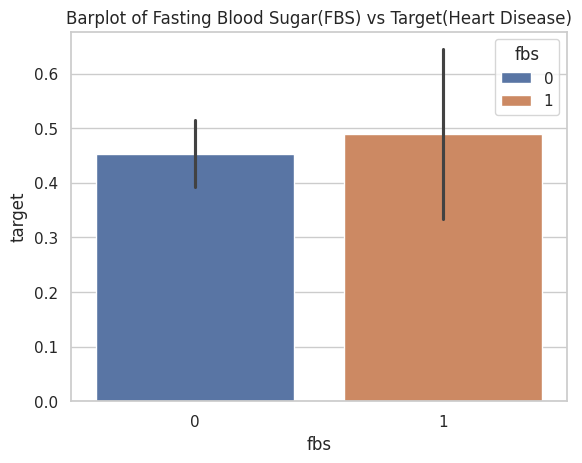

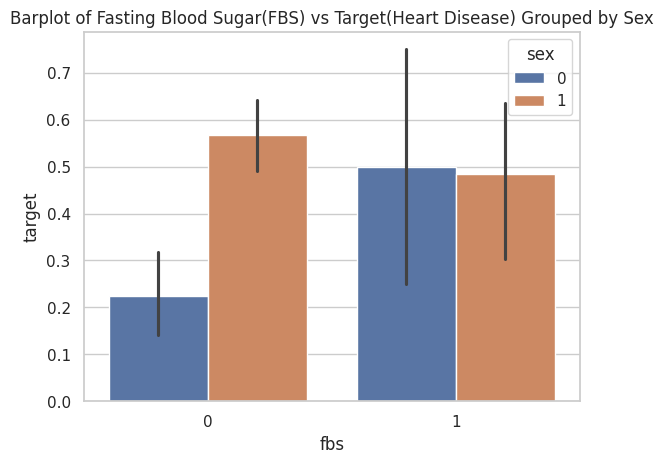

In [ ]:
sns.barplot(x='fbs', y='target',hue='fbs', data=df)
plt.title("Barplot of Fasting Blood Sugar(FBS) vs Target(Heart Disease)")
plt.show()

sns.barplot(x='fbs', y='target', hue='sex', data=df)
plt.title("Barplot of Fasting Blood Sugar(FBS) vs Target(Heart Disease) Grouped by Sex")
plt.show()

Individuals having Fasting blood pressure is almost similar for male and female.

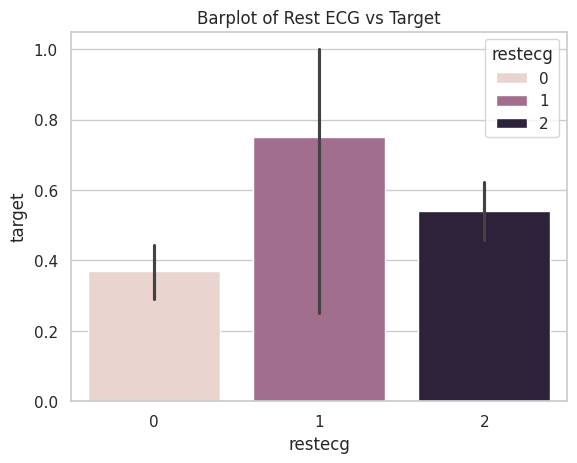

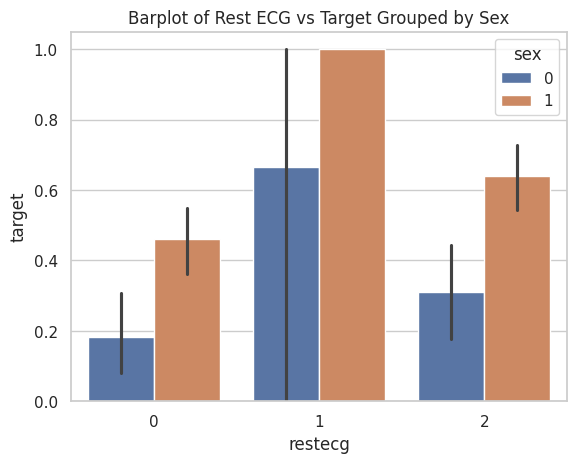

In [ ]:
sns.barplot(x='restecg', y='target',hue='restecg', data=df)
plt.title("Barplot of Rest ECG vs Target")
plt.show()

sns.barplot(x='restecg', y='target', hue='sex', data=df)
plt.title("Barplot of Rest ECG vs Target Grouped by Sex")
plt.show()



*   Restecg values 1(Having ST-T wave abnormality) and 2(Showing probable or definite left ventricular hypertrophy) having more heart diseases.
*   Also, female patients having high restecg values.



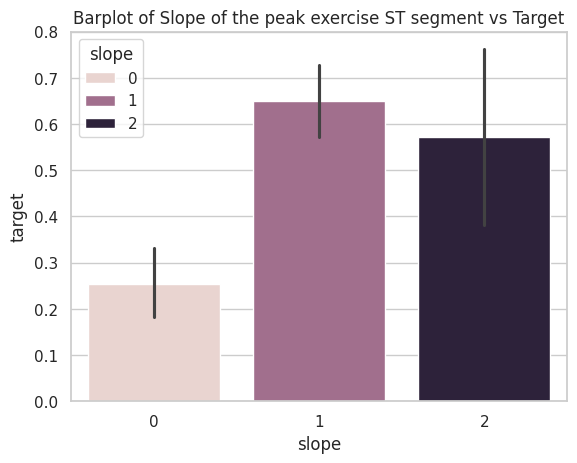

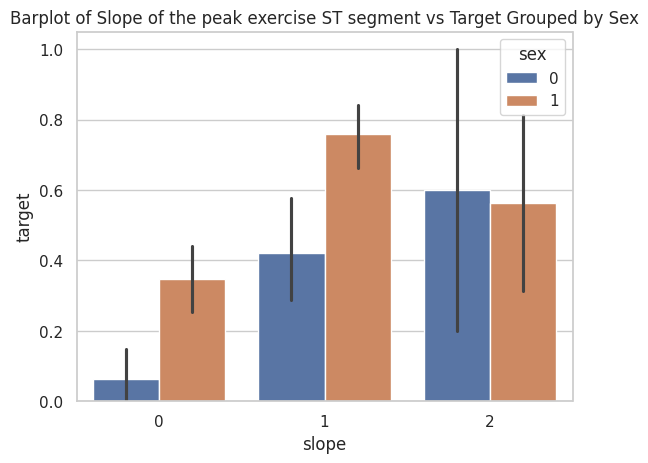

In [ ]:
sns.barplot(x='slope', y='target', hue='slope', data=df)
plt.title("Barplot of Slope of the peak exercise ST segment vs Target")
plt.show()

sns.barplot(x='slope', y='target', hue='sex', data=df)
plt.title("Barplot of Slope of the peak exercise ST segment vs Target Grouped by Sex")
plt.show()



*   Individuals having Slope 1 and 2 has high rate of heart disease.



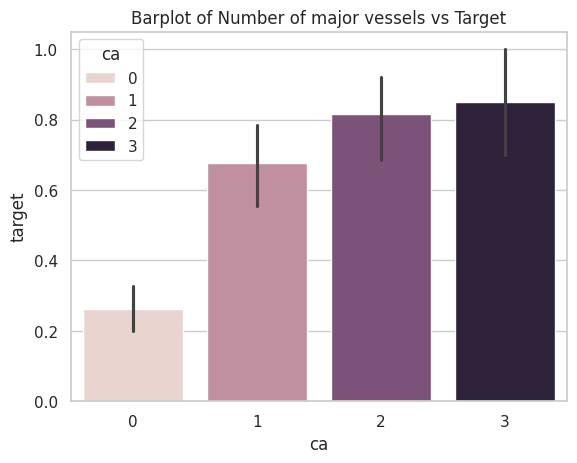

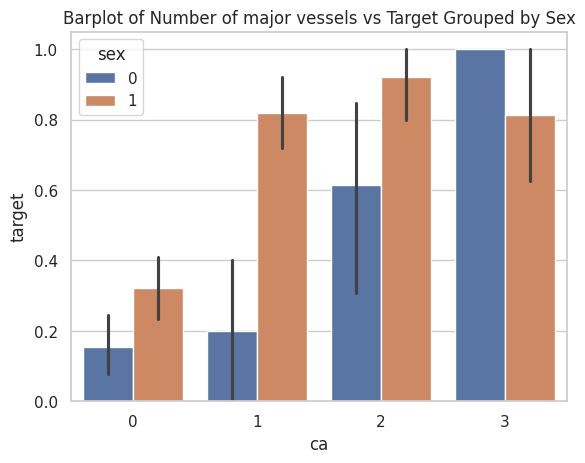

In [ ]:
sns.barplot(x='ca', y='target',hue='ca', data=df)
plt.title("Barplot of Number of major vessels vs Target")
plt.show()

sns.barplot(x='ca', y='target', hue='sex', data=df)
plt.title("Barplot of Number of major vessels vs Target Grouped by Sex")
plt.show()



*   Heart vessels having colours 2 and 3 appears to have more heart disease rate while comparing with other.


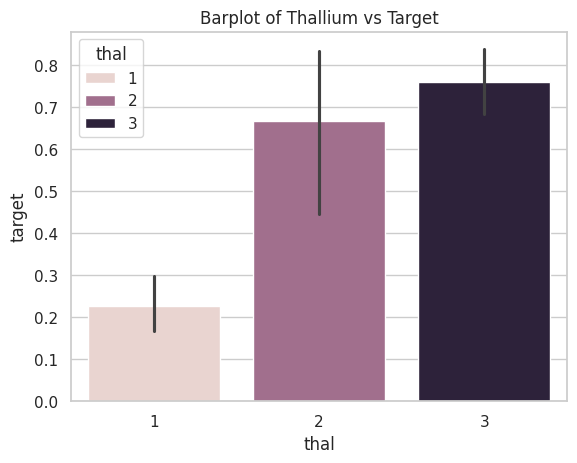

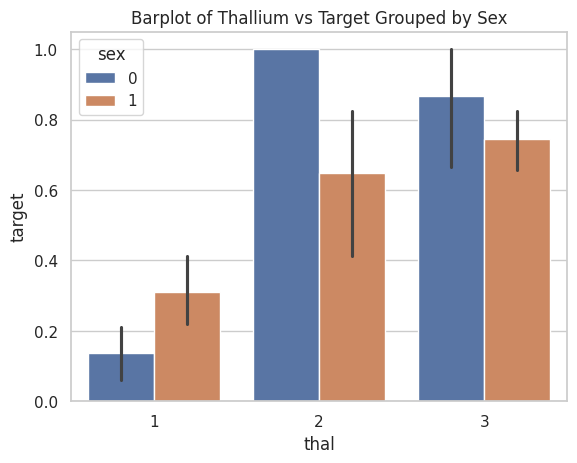

In [ ]:
sns.barplot(x='thal', y='target', hue='thal', data=df)
plt.title("Barplot of Thallium vs Target")
plt.show()

sns.barplot(x='thal', y='target', hue='sex', data=df)
plt.title("Barplot of Thallium vs Target Grouped by Sex")
plt.show()

Visualization of numerical data

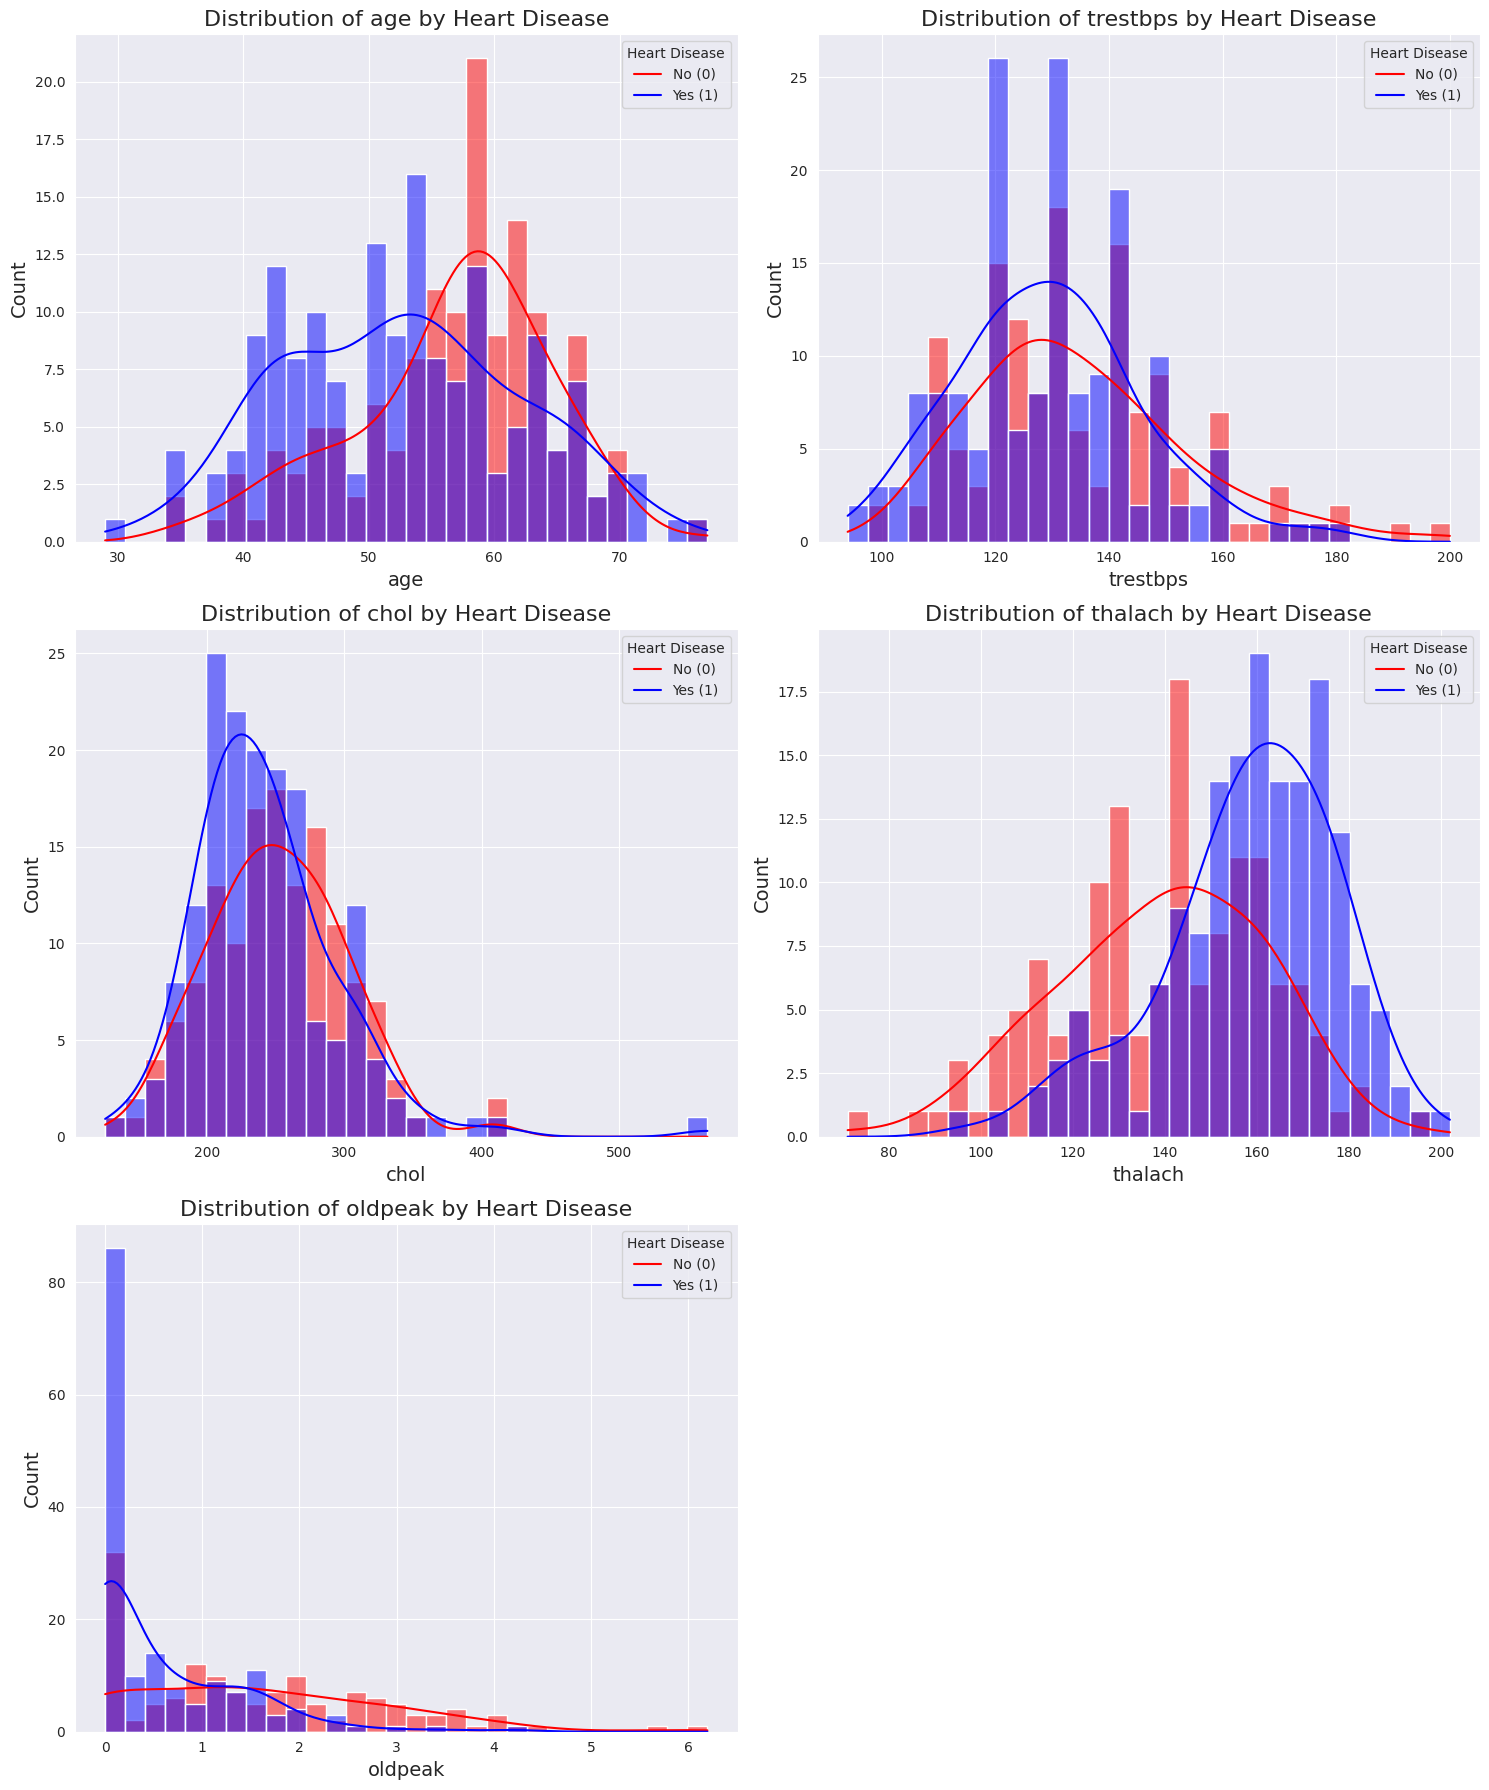

In [7]:
numerical = df[['age', 'trestbps', 'chol', 'thalach', 'oldpeak']]

sns.set_style('darkgrid')
plt.figure(figsize=(15, 18))  # Adjust canvas size
plotno = 1  # Counter

for column in numerical.columns:  # Iterate over numerical columns
    if plotno <= 5:  # Ensure correct number of plots
        plt.subplot(3, 2, plotno)  # Create subplots (3 rows, 2 columns)

        # Plot numerical variables with respect to the binary target variable
        sns.histplot(data=df, x=column, hue='target', kde=True, bins=30, multiple="layer", palette=['blue', 'red'])

        plt.ylabel('Count', fontsize=14)  # Label y-axis
        plt.xlabel(column, fontsize=14)  # Label x-axis
        plt.title(f'Distribution of {column} by Heart Disease', fontsize=16)
        plt.legend(title="Heart Disease", labels=["No (0)", "Yes (1)"])  # Custom legend labels

        plotno += 1  # Increment counter

plt.tight_layout()
plt.show()


# **Outlier Analysis**

In [47]:
df = pd.read_csv('https://raw.githubusercontent.com/abdelDebug/Heart-Disease-Data/refs/heads/main/heart_disease.csv')

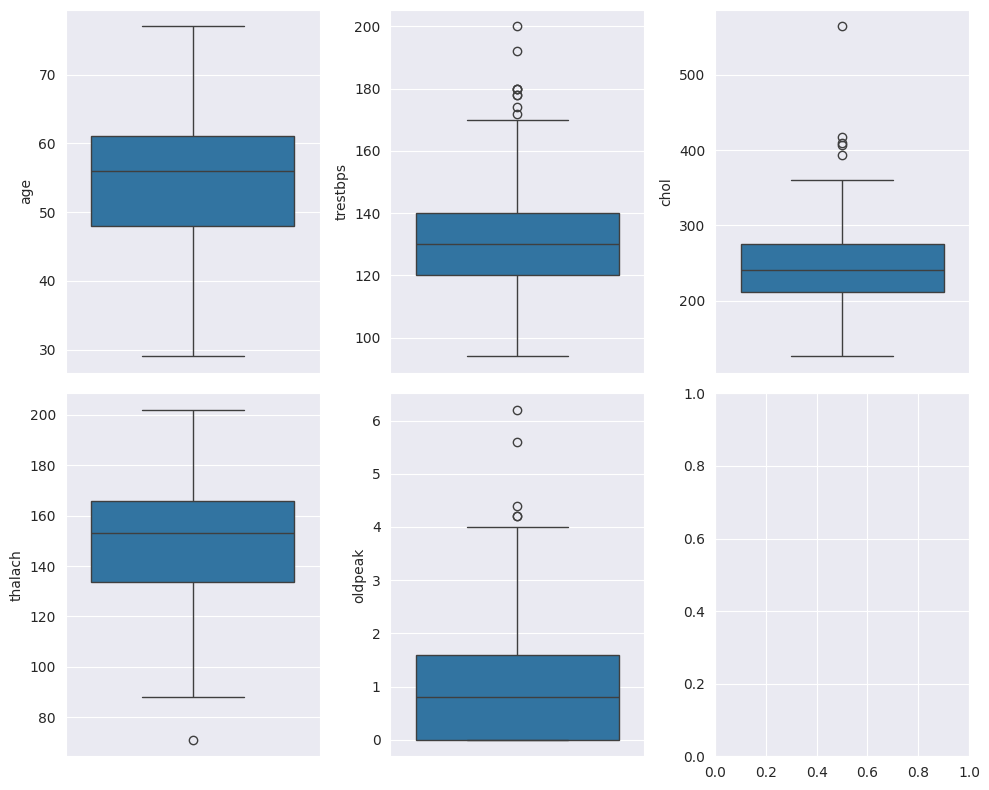

In [4]:
fig, axs = plt.subplots(2,3, figsize = (10,8))
plt1 = sns.boxplot(df['age'], ax = axs[0,0])
plt2 = sns.boxplot(df['trestbps'], ax = axs[0,1])
plt3 = sns.boxplot(df['chol'], ax = axs[0,2])
plt1 = sns.boxplot(df['thalach'], ax = axs[1,0])
plt2 = sns.boxplot(df['oldpeak'], ax = axs[1,1])

plt.tight_layout()

Treating Outliers for trestbps

In [5]:
# Calculate IQR and filter out outliers
Q1 = df.trestbps.quantile(0.25)
Q3 = df.trestbps.quantile(0.75)
IQR = Q3 - Q1
min_limit = Q1 - 1.5*IQR
max_limit = Q3 + 1.5*IQR
print("IQR:", IQR)
print("Min Limit:", min_limit)
print("Max Limit:", max_limit)

# Count the number of outliers
outlier_count = df.loc[df['trestbps'] > max_limit].shape[0]

total_data_points = df.shape[0]
percentage_outliers = (outlier_count / total_data_points) * 100
print(f"Percentage of outliers in 'trestbps': {percentage_outliers:.2f}%")

IQR: 20.0
Min Limit: 90.0
Max Limit: 170.0
Percentage of outliers in 'trestbps': 2.97%


In [6]:
df.loc[df['trestbps'] > max_limit]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
14,52,1,2,172,199,1,0,162,0,0.5,0,0,3,0
83,68,1,2,180,274,1,2,150,1,1.6,1,0,3,1
126,56,0,3,200,288,1,2,133,1,4.0,2,2,3,1
172,59,0,3,174,249,0,0,143,1,0.0,1,0,1,1
183,59,1,0,178,270,0,2,145,0,4.2,2,0,3,0
188,54,1,1,192,283,0,2,195,0,0.0,0,1,3,1
201,64,0,3,180,325,0,0,154,1,0.0,0,0,1,0
213,66,0,3,178,228,1,0,165,1,1.0,1,2,3,1
231,55,0,3,180,327,0,1,117,1,3.4,1,0,1,1


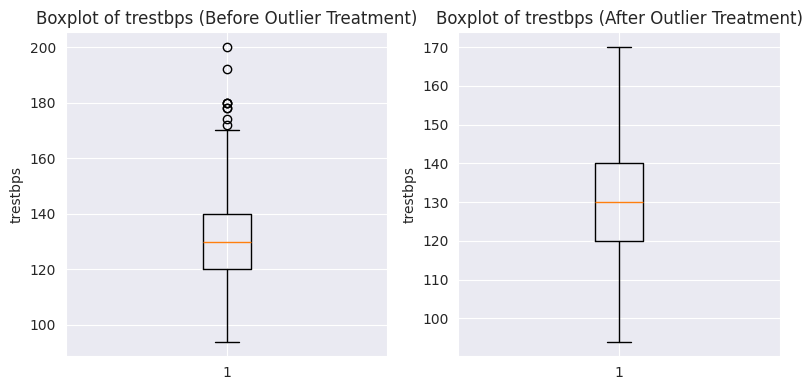

In [7]:
plt.figure(figsize=(8, 4))
# Plot boxplot before outlier treatment on trestbps
plt.subplot(1, 2, 1)
plt.boxplot(df.trestbps)
plt.title("Boxplot of trestbps (Before Outlier Treatment)")
plt.ylabel("trestbps")


# Imputation of outlier
df.loc[df['trestbps'] > max_limit ,'trestbps']=np.median(df['trestbps'])

# Plot boxplot after outlier treatment on trestbps
plt.subplot(1, 2, 2)
plt.boxplot(df.trestbps)
plt.title("Boxplot of trestbps (After Outlier Treatment)")
plt.ylabel("trestbps")

# Adjust layout and display
plt.tight_layout()
plt.show()

In [10]:
count_outliers = df.loc[df['trestbps'] > max_limit].shape[0]
print(f"Number of rows with 'trestbps' greater than {max_limit}(max limit) =  {count_outliers}")

Number of rows with 'trestbps' greater than 170.0(max limit) =  0


We have decided to treat the outlier using imputation because we only have 303 data and removing a significant data from dataset may affect the model.

Trating outliers for Chol

In [8]:
# Calculate IQR and filter out outliers
Q1 = df.chol.quantile(0.25)
Q3 = df.chol.quantile(0.75)
IQR = Q3 - Q1
min_limit = Q1 - 1.5*IQR
max_limit = Q3 + 1.5*IQR
print("IQR:", IQR)
print("Min Limit:", min_limit)
print("Max Limit:", max_limit)

# Count the number of outliers
outlier_count = df.loc[df['chol'] > max_limit].shape[0]

# Calculate the total number of data points
total_data_points = df.shape[0]

# Calculate the percentage of outliers
percentage_outliers = (outlier_count / total_data_points) * 100

# Print the percentage of outliers
print(f"Percentage of outliers in 'chol': {percentage_outliers:.2f}%")

IQR: 64.0
Min Limit: 115.0
Max Limit: 371.0
Percentage of outliers in 'chol': 1.65%


In [9]:
df.loc[df['chol'] > max_limit]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
48,65,0,2,140,417,1,2,157,0,0.8,0,1,1,0
121,63,0,3,150,407,0,2,154,0,4.0,1,3,3,1
152,67,0,2,115,564,0,2,160,0,1.6,1,0,3,0
173,62,0,3,140,394,0,2,157,0,1.2,1,0,1,0
181,56,0,3,134,409,0,2,150,1,1.9,1,2,3,1


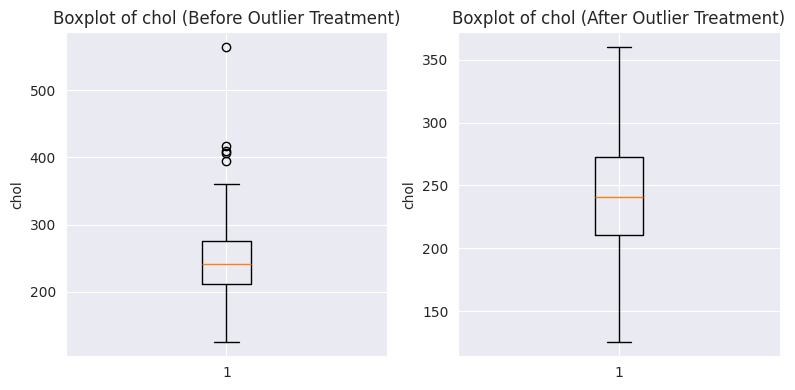

In [10]:
plt.figure(figsize=(8, 4))
# Plot boxplot before outlier treatment on chol
plt.subplot(1, 2, 1)
plt.boxplot(df.chol)
plt.title("Boxplot of chol (Before Outlier Treatment)")
plt.ylabel("chol")


# Imputation of outlier
df.loc[df['chol'] > max_limit ,'chol']=np.median(df['chol'])

# Plot boxplot after outlier treatment on trestbps
plt.subplot(1, 2, 2)
plt.boxplot(df.chol)
plt.title("Boxplot of chol (After Outlier Treatment)")
plt.ylabel("chol")

# Adjust layout and display
plt.tight_layout()
plt.show()

In [11]:
count_outliers = df.loc[df['chol'] > max_limit].shape[0]
print(f"Number of rows with 'chol' greater than {max_limit}(max limit) =  {count_outliers}")

Number of rows with 'chol' greater than 371.0(max limit) =  0


Like we did on trestbps, here also implimented the imputation for handling the outliers in chol. After imputation there is no outlier in chol.

Thalach and oldpeak oulier is comparitively very small and can be ignored.

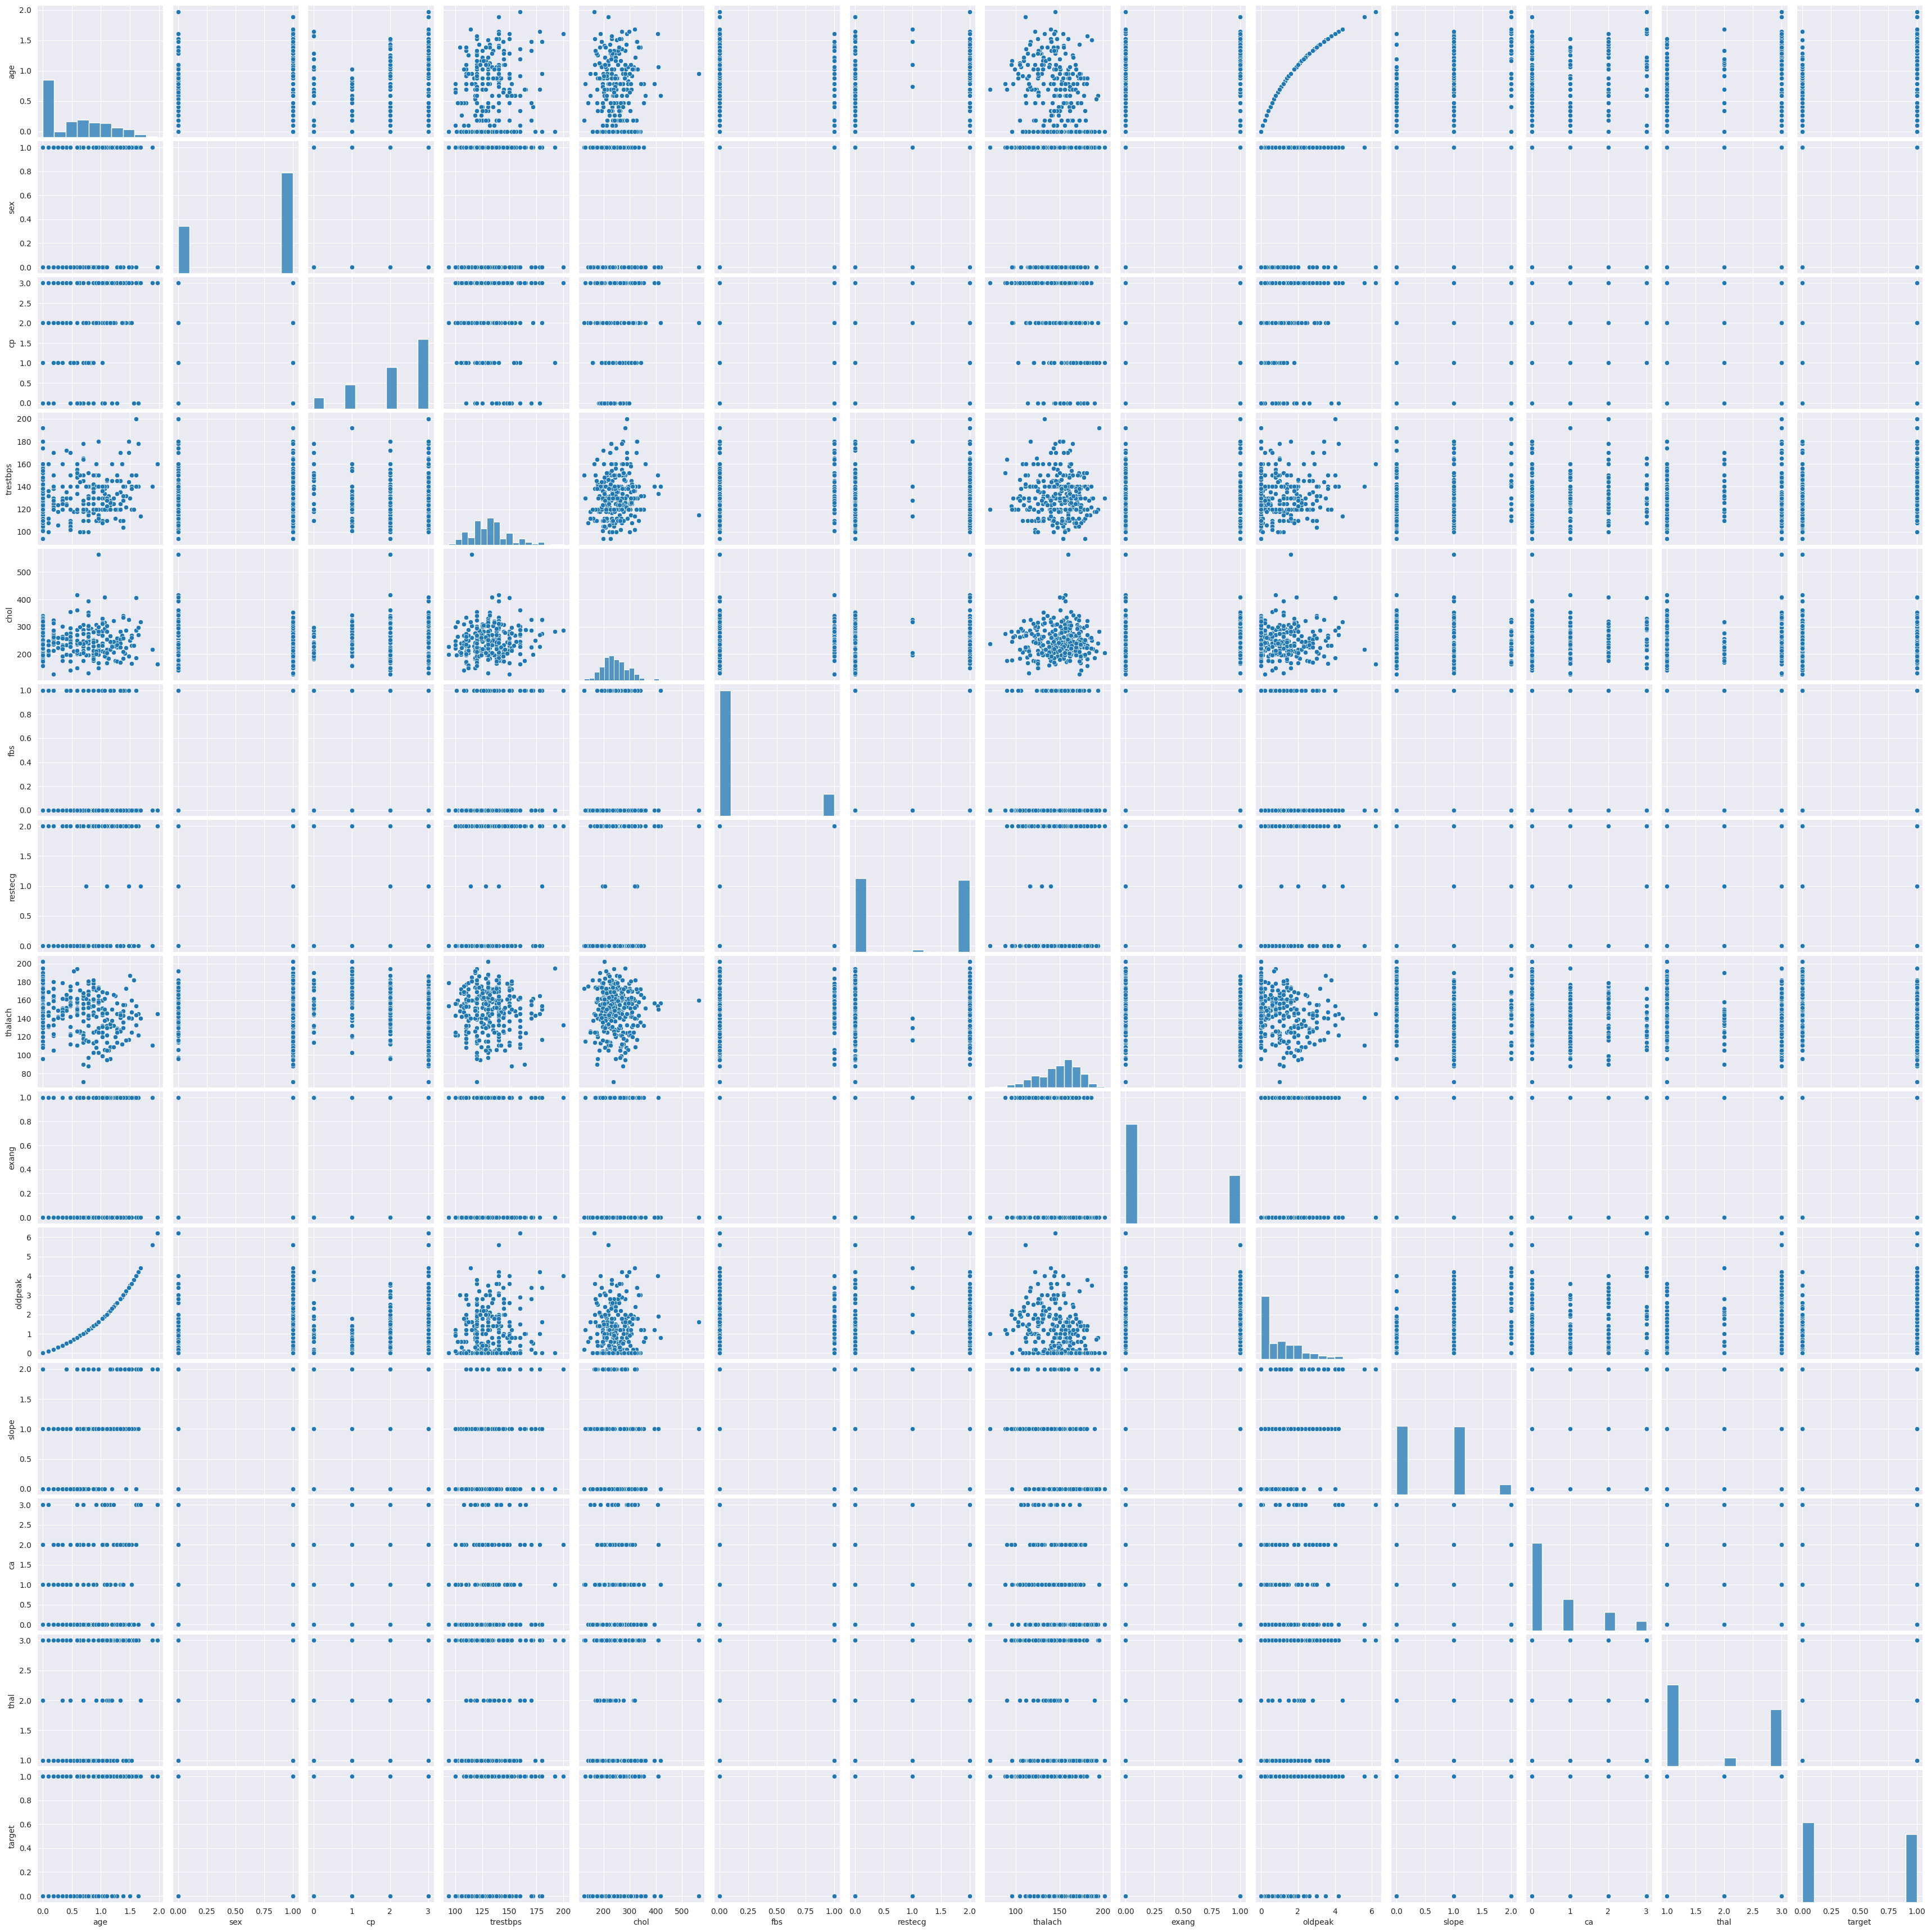

In [51]:
sns.pairplot(df)
plt.show()

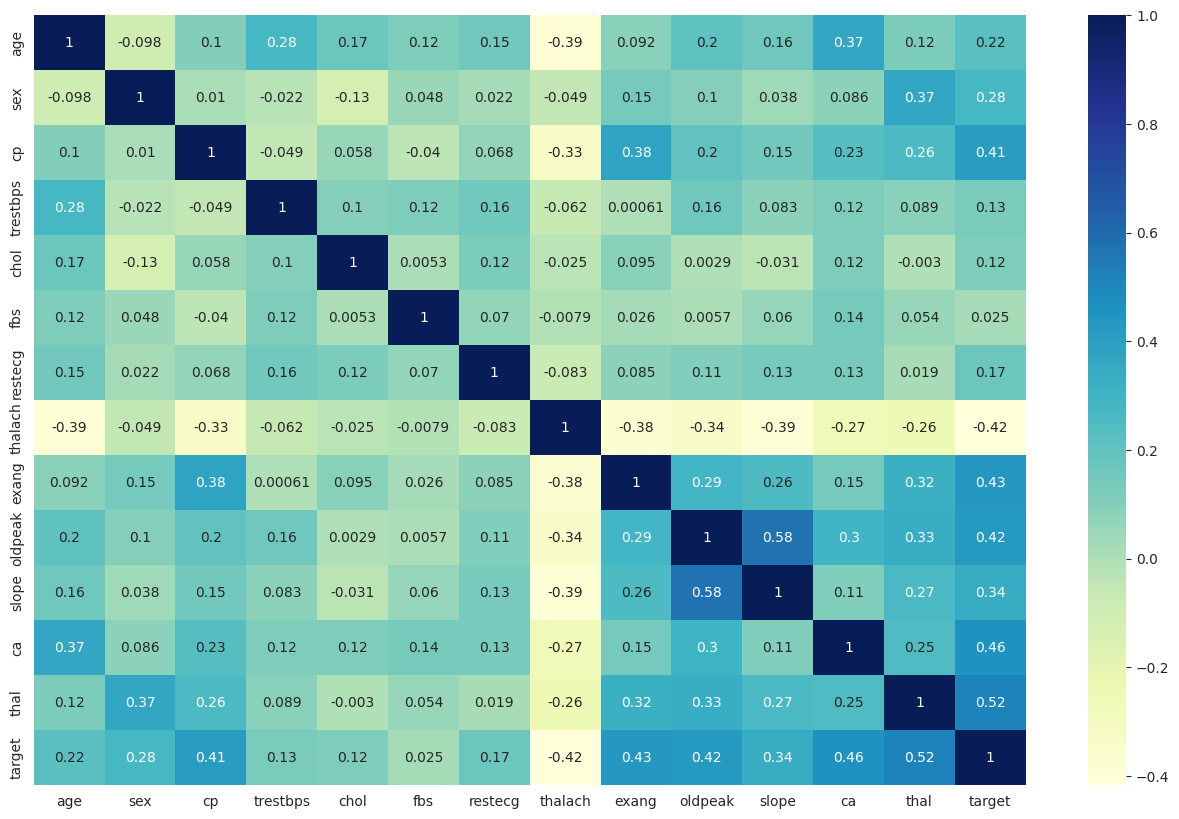

In [12]:
plt.figure(figsize = (16, 10))
sns.heatmap(df.corr(), annot = True, cmap="YlGnBu")
plt.show()

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score , confusion_matrix , ConfusionMatrixDisplay, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_recall_curve
import shap
import xgboost as xgb
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [4]:
x = df.drop(columns=['target'])
y = df['target']

In [5]:
# We specify this so that the train and test data set always have the same rows, respectively
np.random.seed(0)
X_train, X_test, y_train, y_test = train_test_split(x, y, train_size = 0.8, test_size = 0.2, random_state = 42,stratify=y)

In [8]:
scaler = StandardScaler()
numeric_scalable_features = numerical.columns
# Fit on training data only and transform training data
X_train[numeric_scalable_features] = scaler.fit_transform(X_train[numeric_scalable_features])

# Transform the test data using the same scaler (do not fit again)
X_test[numeric_scalable_features] = scaler.transform(X_test[numeric_scalable_features])

In [18]:
X_train.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
count,2.420000e+02,242.000000,242.000000,2.420000e+02,2.420000e+02,242.000000,242.000000,2.420000e+02,242.000000,242.000000,242.000000,242.000000,242.000000
mean,-1.835079e-16,0.681818,2.152893,-1.651571e-16,1.761676e-16,0.144628,0.979339,-7.340318e-18,0.326446,0.000000,0.586777,0.607438,1.830579
std,1.002073e+00,0.466736,0.975516,1.002073e+00,1.002073e+00,0.352454,0.999786,1.002073e+00,0.469885,1.002073,0.613397,0.882534,0.964201
min,-2.845681e+00,0.000000,0.000000,-2.316991e+00,-2.711897e+00,0.000000,0.000000,-3.487829e+00,0.000000,-0.891627,0.000000,0.000000,1.000000
25%,-7.294848e-01,0.000000,1.250000,-6.261412e-01,-7.645484e-01,0.000000,0.000000,-6.830006e-01,0.000000,-0.891627,0.000000,0.000000,1.000000
50%,1.615452e-01,1.000000,2.000000,2.418571e-02,-6.259734e-02,0.000000,0.000000,1.562396e-01,0.000000,-0.177735,1.000000,0.000000,1.000000
75%,7.184390e-01,1.000000,3.000000,6.745127e-01,6.563364e-01,0.000000,2.000000,7.083712e-01,1.000000,0.536156,1.000000,1.000000,3.000000
max,2.500499e+00,1.000000,3.000000,2.625493e+00,2.586702e+00,1.000000,2.000000,2.298510e+00,1.000000,4.641035,2.000000,3.000000,3.000000


In [9]:
print(X_train.shape, X_test.shape)

(242, 13) (61, 13)


In [21]:
model = DecisionTreeClassifier(criterion="gini", max_depth=5, random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

              precision    recall  f1-score   support

           0       0.86      0.73      0.79        33
           1       0.73      0.86      0.79        28

    accuracy                           0.79        61
   macro avg       0.79      0.79      0.79        61
weighted avg       0.80      0.79      0.79        61



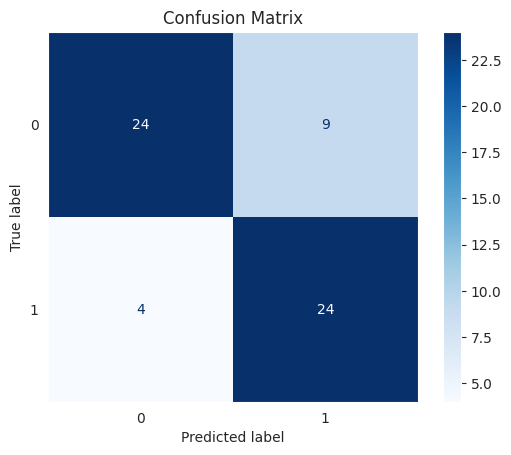

In [22]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test , y_pred)
print(classification_report(y_test, y_pred))

conf_matrix = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=model.classes_)
disp.plot(cmap="Blues", values_format='')
plt.grid(False)
plt.title("Confusion Matrix")
plt.show()

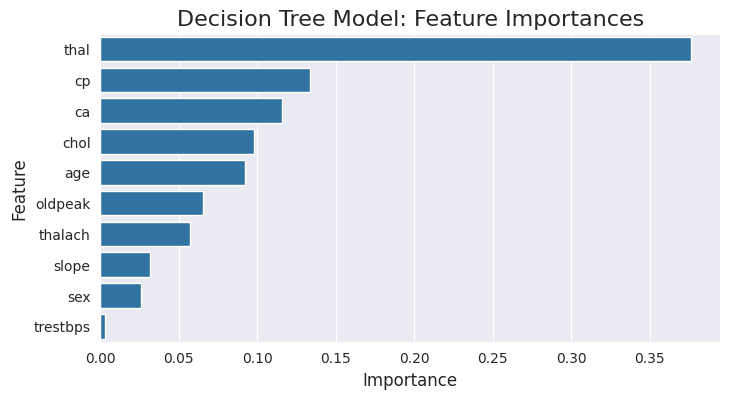

In [23]:
feature_importances = pd.DataFrame(model.feature_importances_, columns=['gini_importance'], index=X_train.columns)
feature_importances = feature_importances.sort_values(by='gini_importance', ascending=False)
feature_importances = feature_importances[feature_importances['gini_importance'] != 0]

plt.figure(figsize=(8, 4))
sns.barplot(data=feature_importances,
            x='gini_importance',
            y=feature_importances.index,
            orient='h')
plt.title('Decision Tree Model: Feature Importances', fontsize=16)
plt.ylabel('Feature', fontsize=12)
plt.xlabel('Importance', fontsize=12)
plt.show()

In [22]:
model = LogisticRegression(max_iter=10000, random_state=17)
model.fit(X_train, y_train)

LogisticRegression(max_iter=10000, random_state=17)

              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



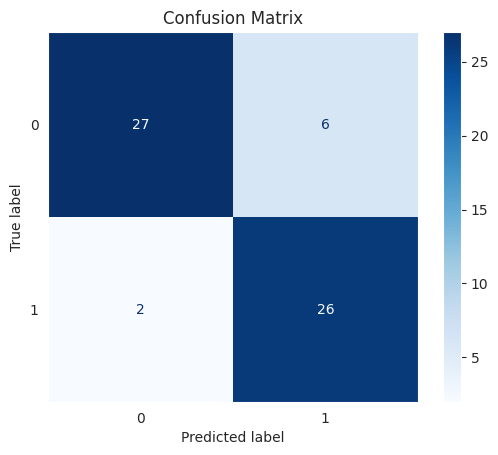

In [23]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(classification_report(y_test, y_pred))

conf_matrix = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=model.classes_)
disp.plot(cmap="Blues", values_format='')
plt.grid(False)
plt.title("Confusion Matrix")
plt.show()

In [24]:
model = SVC(kernel='linear', random_state=42)
model.fit(X_train, y_train)

SVC(kernel='linear', random_state=42)

              precision    recall  f1-score   support

           0       0.90      0.82      0.86        33
           1       0.81      0.89      0.85        28

    accuracy                           0.85        61
   macro avg       0.85      0.86      0.85        61
weighted avg       0.86      0.85      0.85        61



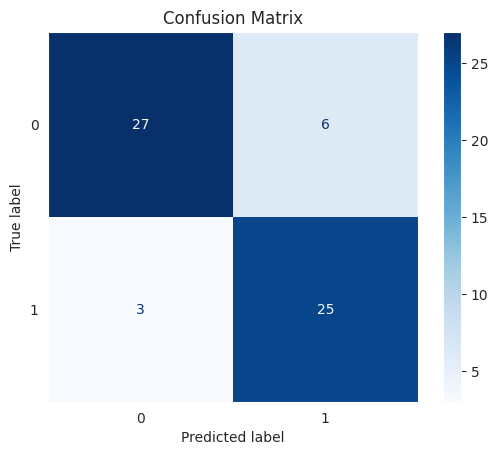

In [25]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(classification_report(y_test, y_pred))

conf_matrix = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=model.classes_)
disp.plot(cmap="Blues", values_format='')
plt.grid(False)
plt.title("Confusion Matrix")
plt.show()

In [26]:
model = GaussianNB()
model.fit(X_train, y_train)

GaussianNB()

              precision    recall  f1-score   support

           0       0.96      0.79      0.87        33
           1       0.79      0.96      0.87        28

    accuracy                           0.87        61
   macro avg       0.88      0.88      0.87        61
weighted avg       0.89      0.87      0.87        61



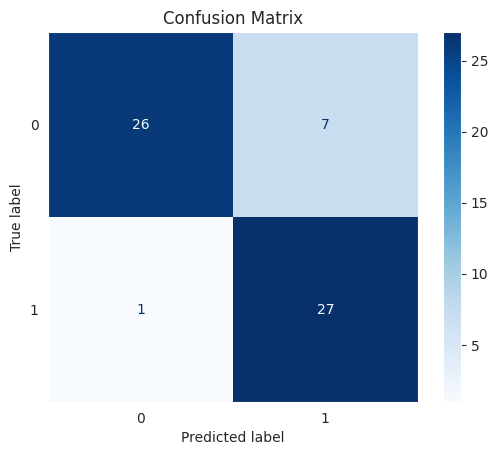

In [27]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(classification_report(y_test, y_pred))

conf_matrix = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=model.classes_)
disp.plot(cmap="Blues", values_format='')
plt.grid(False)
plt.title("Confusion Matrix")
plt.show()

In [28]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



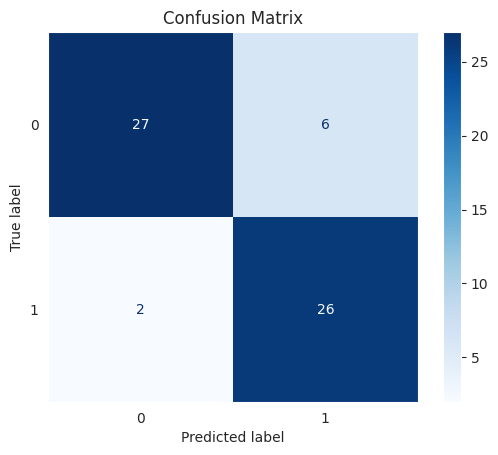

In [29]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(classification_report(y_test, y_pred))

conf_matrix = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=model.classes_)
disp.plot(cmap="Blues", values_format='')
plt.grid(False)
plt.title("Confusion Matrix")
plt.show()

In [21]:
model = XGBClassifier(random_state=42)
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

              precision    recall  f1-score   support

           0       0.93      0.79      0.85        33
           1       0.79      0.93      0.85        28

    accuracy                           0.85        61
   macro avg       0.86      0.86      0.85        61
weighted avg       0.86      0.85      0.85        61



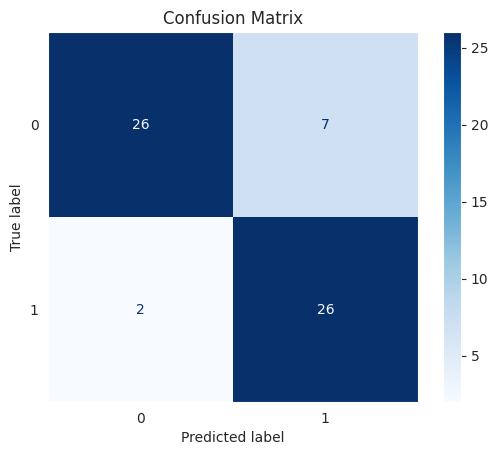

In [13]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(classification_report(y_test, y_pred))

conf_matrix = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=model.classes_)
disp.plot(cmap="Blues", values_format='')
plt.grid(False)
plt.title("Confusion Matrix")
plt.show()

In [19]:
model = GradientBoostingClassifier( random_state=42)
model.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

              precision    recall  f1-score   support

           0       0.93      0.79      0.85        33
           1       0.79      0.93      0.85        28

    accuracy                           0.85        61
   macro avg       0.86      0.86      0.85        61
weighted avg       0.86      0.85      0.85        61



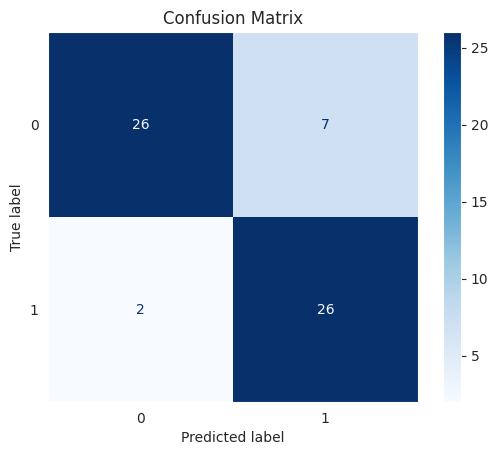

In [20]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(classification_report(y_test, y_pred))

conf_matrix = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=model.classes_)
disp.plot(cmap="Blues", values_format='')
plt.grid(False)
plt.title("Confusion Matrix")
plt.show()